<a href="https://colab.research.google.com/github/DavidBond228/LAB1-Linear-/blob/main/LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import numpy as np
import matplotlib.pyplot as plt

In [74]:
X = np.array([[0, 0, 0, 2, 0, 2],
              [0, 4, 2, 4, 2, 0]])

In [75]:
def show(orig, transf):
    plt.plot(orig[0], orig[1], 'b-o')
    plt.plot(transf[0], transf[1], 'r-o')
    plt.axis('equal')
    plt.grid(True)
    plt.show()

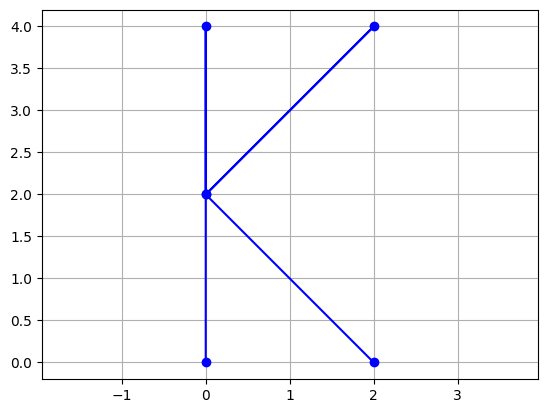

In [76]:
plt.plot(X[0], X[1], 'b-o')
plt.axis('equal')
plt.grid(True)
plt.show()

In [77]:
S = np.array([[2,0],[0,1]])

In [78]:
X_new = S @ X

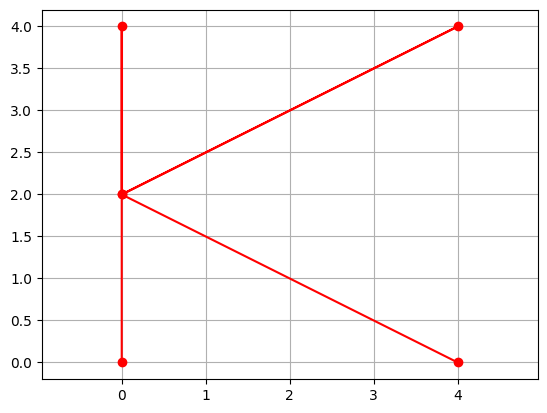

In [79]:
plt.plot(X_new[0], X_new[1], 'r-o')
plt.axis('equal')
plt.grid(True)
plt.show()

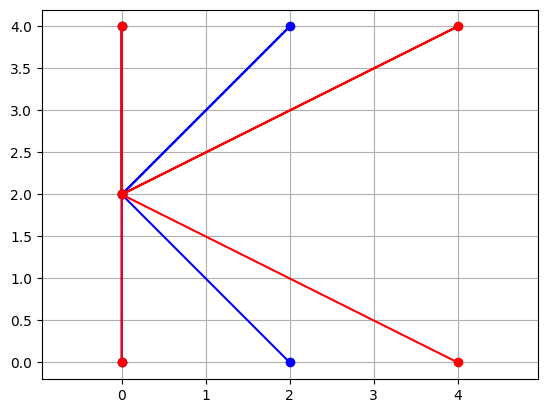

In [80]:
plt.plot(X[0],X[1] , 'b-o')
plt.plot(X_new[0], X_new[1] , 'r-o')
plt.axis('equal')
plt.grid(True)
plt.show()

In [81]:
def stretch(X, a, b):
    X = X.copy()
    S = np.array([[a, 0], [0, b]])
    return S @ X

Матриця stretch:
[[2 0]
 [0 1]]


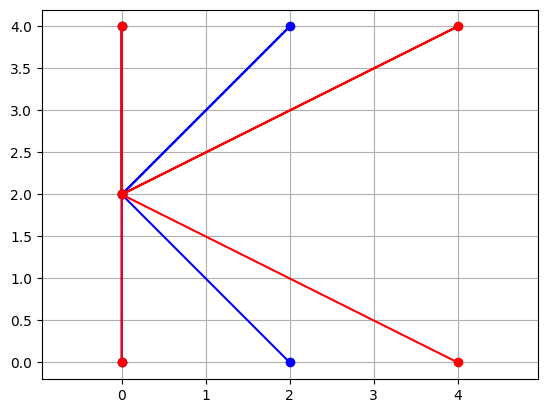

In [82]:
S = np.array([[2, 0], [0, 1]])
print("Матриця stretch:")
print(S)
show(X, stretch(X, 2, 1))

In [83]:
def shear(X, a, b):
    X = X.copy()
    S = np.array([[1, a], [b, 1]])
    return S @ X

Матриця shear:
[[1.  0.5]
 [0.  1. ]]


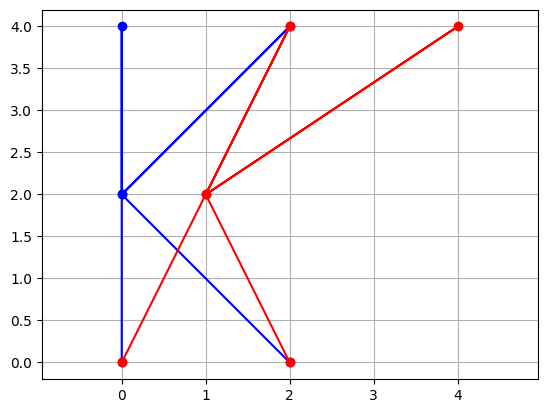

In [84]:
S = np.array([[1, 0.5], [0, 1]])
print("Матриця shear:")
print(S)
show(X, shear(X, 0.5, 0))

In [95]:
def reflection(X, a, b):
    X = X.copy()
    S = (1 / (a**2 + b**2)) * np.array([[a**2 - b**2, 2*a*b], [2*a*b, b**2 - a**2]])
    return S @ X

In [86]:
def rotation(X, theta):
    X = X.copy()
    S = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    return S @ X

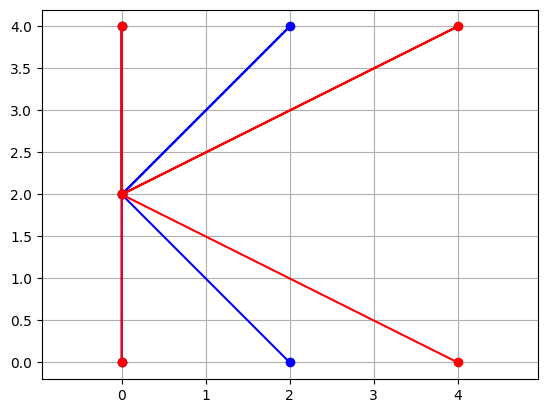

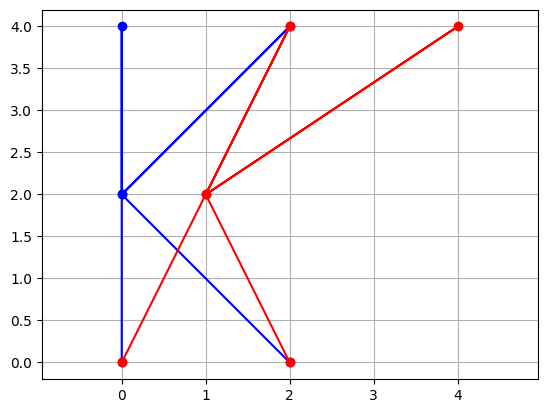

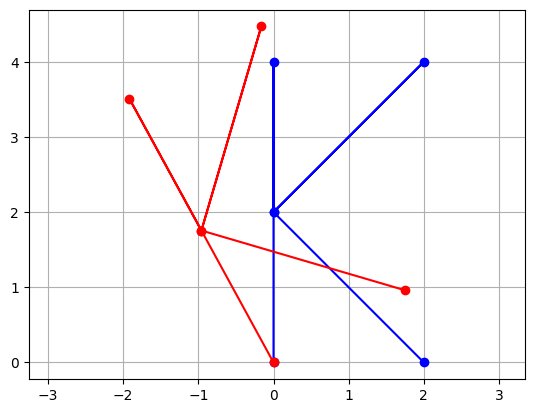

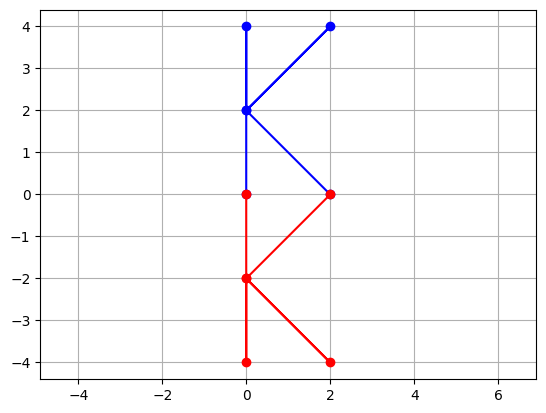

In [87]:
show(X, stretch(X, 2, 1))
show(X, shear(X, 0.5, 0))
show(X, rotation(X, 0.5))
show(X, reflection(X, 1, 0))

In [88]:
print("stretch:")
print(np.array([[2, 0], [0, 1]]))
print("shear:")
print(np.array([[1, 0.5], [0, 1]]))
print("rotation:")
print(np.array([[np.cos(0.5), -np.sin(0.5)], [np.sin(0.5), np.cos(0.5)]]))
print("reflection:")
print(np.array([[1, 0], [0, -1]]))

stretch:
[[2 0]
 [0 1]]
shear:
[[1.  0.5]
 [0.  1. ]]
rotation:
[[ 0.87758256 -0.47942554]
 [ 0.47942554  0.87758256]]
reflection:
[[ 1  0]
 [ 0 -1]]



Матриця перетворення [[a, b], [c, d]]:
- a, d - діагональні елементи -  масштабування по осях X та Y
- b, c — позадіагональні -  зсув вздовж осей
- зміна знаку a або d — відображення (reflection)
- det = 1 - площа зберігається; |det| > 1 — збільшується; det = 0 — фігура схлопується.

In [89]:
rotation( shear(X, 0.5, 0),  0.5)

array([[ 0.        , -0.16253703, -0.08126852,  1.59262809, -0.08126852,
         1.75516512],
       [ 0.        ,  4.46918132,  2.23459066,  5.4280324 ,  2.23459066,
         0.95885108]])

In [90]:
shear(rotation(X, 0.5), 0.5, 0)

array([[ 0.        , -0.16253703, -0.08126852,  2.07205363, -0.08126852,
         2.23459066],
       [ 0.        ,  3.51033025,  1.75516512,  4.46918132,  1.75516512,
         0.95885108]])

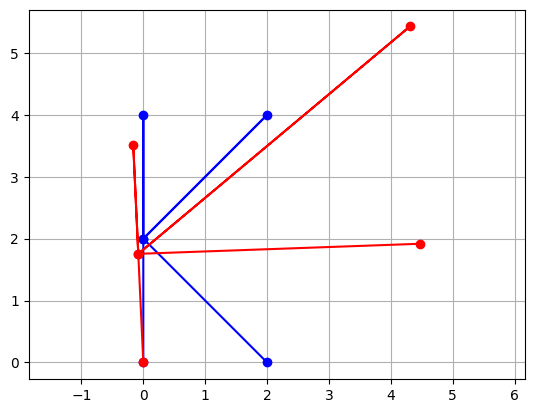

In [91]:
show(X, shear(rotation(stretch(X, 2, 1), 0.5), 0.5, 0))

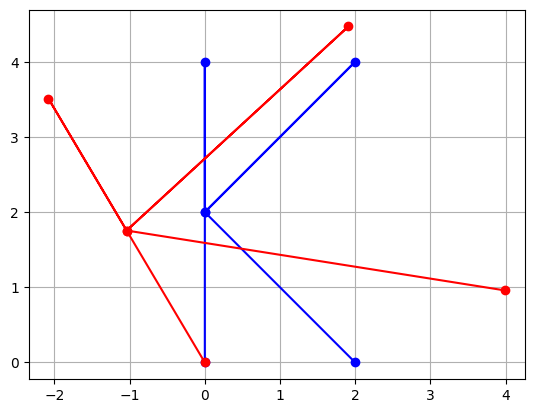

In [92]:
b1 = rotation(X, 0.5)
b2 = stretch(b1, 2, 1)
b3 = shear(b2, 0.5, 0)
show(X, b3)

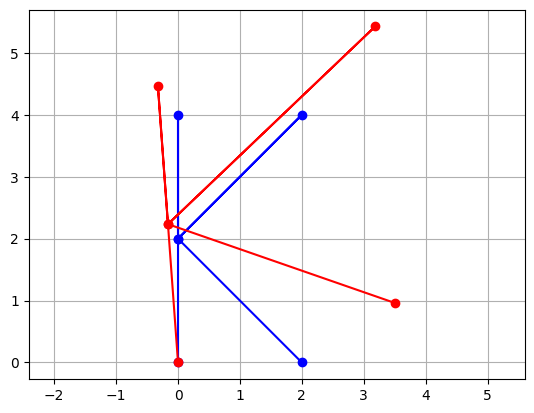

In [93]:
c1 = shear(X, 0.5, 0)
c2 = rotation(c1, 0.5)
c3 = stretch(c2, 2, 1)
show(X, c3)

Результат залежить від порядку трансформацій. Ті самі stretch, shear, rotation у різній послідовності дають різні фігури - множення матриць некомутативне.

In [94]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"davidtepanian","key":"3813427bb0d8c577ae3fe933440b9a16"}'}

In [ ]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
!cp kaggle.json /root/.config/kaggle/
!chmod 600 /root/.config/kaggle/kaggle.json
!pip install kaggle -q

In [ ]:
!kaggle datasets download -d balraj98/modelnet40-princeton-3d-object-dataset -f ModelNet40/airplane/train/airplane_0001.off
!unzip -o airplane_0001.off.zip

In [ ]:
def read_off(filename):
    with open(filename, 'r') as f:
        if 'OFF' != f.readline().strip():
            raise ValueError('Not a valid OFF header')
        n_verts, n_faces, _ = map(int, f.readline().strip().split())
        verts = [list(map(float, f.readline().strip().split())) for _ in range(n_verts)]
        faces = [list(map(int, f.readline().strip().split()[1:])) for _ in range(n_faces)]
    return np.array(verts), faces

vertices, faces = read_off("airplane_0001.off")
print("Форма вершин:",vertices.shape)

In [ ]:
X3 = vertices.T
print("Nova форма:", X3.shape)

In [ ]:
def rotate_xy(X, theta):
    X = X.copy()
    S = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta),  np.cos(theta), 0],
                  [0,              0,             1]])
    return S @ X

In [ ]:
def rotate_yz(X, theta):
    X = X.copy()
    S = np.array([[1, 0,             0],
                  [0, np.cos(theta), -np.sin(theta)],
                  [0, np.sin(theta),  np.cos(theta)]])
    return S @ X

In [ ]:
def rotate_xz(X, theta):
    X = X.copy()
    S = np.array([[np.cos(theta), 0, -np.sin(theta)],
                  [0,             1,  0],
                  [np.sin(theta), 0,  np.cos(theta)]])
    return S @ X

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_off(vertices, faces, title=""):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection([vertices[face] for face in faces], alpha=0.3, edgecolor='k')
    ax.add_collection3d(mesh)
    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], s=1, c='r')
    ax.set_title(title)
    ax.auto_scale_xyz(vertices[:, 0], vertices[:, 1], vertices[:, 2])
    plt.show()

plot_off(vertices, faces, "Оригінал")

In [ ]:
theta_test = 0.7
res_xy = rotate_xy(X3, theta_test)
print("Матриця rotate_xy:")
print(
    np.array([
        [np.cos(theta_test), -np.sin(theta_test), 0],
        [np.sin(theta_test), np.cos(theta_test), 0],
        [0, 0, 1],
    ])
)
plot_off(res_xy.T, faces, "Rotate XY")

res_yz = rotate_yz(X3, theta_test)
print("Матриця rotate_yz:")
print(
    np.array([
        [1, 0, 0],
        [0, np.cos(theta_test), -np.sin(theta_test)],
        [0, np.sin(theta_test), np.cos(theta_test)],
    ])
)
plot_off(res_yz.T, faces, "Rotate YZ")

res_xz = rotate_xz(X3, theta_test)
print("Матриця rotate_xz:")
print(
    np.array([
        [np.cos(theta_test), 0, -np.sin(theta_test)],
        [0, 1, 0],
        [np.sin(theta_test), 0, np.cos(theta_test)],
    ])
)
plot_off(res_xz.T, faces, "Rotate XZ")

In [ ]:
r1 = rotate_xy(X3, 0.7)
r2 = rotate_yz(r1, 0.8)
r3 = rotate_xz(r2, 0.9)
plot_off(r3.T, faces, "Task 4")

In [ ]:
theta = 0.7
Rxy = np.array([[np.cos(theta),-np.sin(theta),0],[np.sin(theta),np.cos(theta),0],[0,0,1]])
Ryz = np.array([[1,0,0],[0,np.cos(theta),-np.sin(theta)],[0,np.sin(theta),np.cos(theta)]])
Rxz = np.array([[np.cos(theta),0,-np.sin(theta)],[0,1,0],[np.sin(theta),0,np.cos(theta)]])
R_total = Rxz @ Ryz @ Rxy
print("Підсумкова матриця Task 4:")
print(R_total)

In [ ]:
theta = 0.7
print("rotate_xy:")
print(np.array([[np.cos(theta), -np.sin(theta), 0],[np.sin(theta), np.cos(theta), 0],[0,0,1]]))
print("rotate_yz:")
print(np.array([[1,0,0],[0,np.cos(theta), -np.sin(theta)],[0,np.sin(theta), np.cos(theta)]]))
print("rotate_xz:")
print(np.array([[np.cos(theta),0,-np.sin(theta)],[0,1,0],[np.sin(theta),0,np.cos(theta)]]))